In [21]:
import pandas as pd
import geopandas as gpd
import seaborn as sns
from matplotlib import pyplot as plt

import os
import numpy as np
from shapely.geometry import box

from land_cover.load import plot_dir, loadLiu, loadGlobathy, loadGLAKES_GSWL, GLAKES_gswl_pth, GLAKES_gswl_abz_pth
from land_cover.plotting import reg_hexplot

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
# gdf = loadGLAKES_GSWL(filter_matches=True, region=None)  # region="na_abz")

In [4]:
gdf = loadGLAKES_GSWL(filter_matches=True, region="na_abz")

In [5]:
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1276879 entries, 0 to 1276878
Data columns (total 74 columns):
 #   Column              Non-Null Count    Dtype   
---  ------              --------------    -----   
 0   Lake_id             1276879 non-null  int64   
 1   OBJECTID            1276879 non-null  float64 
 2   Area_bound          1276879 non-null  float64 
 3   Area_PW             1276879 non-null  float64 
 4   Continent_left      1276879 non-null  object  
 5   Lat                 1276879 non-null  float64 
 6   Lon                 1276879 non-null  float64 
 7   GFed_flag           1276879 non-null  int64   
 8   PFed_flag           1276879 non-null  int64   
 9   Endo_flag           1276879 non-null  int64   
 10  Rser_flag           1276879 non-null  int64   
 11  Shape_Leng          1276879 non-null  float64 
 12  Shape_Area          1276879 non-null  float64 
 13  areaP1              247170 non-null   float64 
 14  areaP2              247170 non-null   floa

In [6]:
gdf.head()

,Lake_id,OBJECTID,Area_bound,Area_PW,Continent_left,Lat,Lon,GFed_flag,PFed_flag,Endo_flag,...,Zmean_gswl,q_gswl,area_gswl,KG_gswl,LGM_gswl,area_km2_gswl,match_gswl,dyn_ratio_gswl,depth_ratio_gswl,geometry
0,302,302.0,626.492502,603.202180,North America,53.763279,-89.994222,0,1,0,...,10.300000,2.553400,6.388282e+08,27.0,ice,638.828164,1.0,2.384483,0.281421,"MULTIPOLYGON (((-90.3975 53.75275, -90.3985 53..."
1,315,315.0,611.933062,592.830318,North America,50.892010,-76.992578,0,0,0,...,5.100000,1.549020,4.740000e+08,26.0,ice,474.000000,1.0,4.774139,0.392308,"MULTIPOLYGON (((-76.9965 51.24, -76.99625 51.2..."
2,360,360.0,527.710871,495.214236,North America,60.026532,-104.493954,0,1,0,...,10.859944,2.459219,5.440978e+08,27.0,ice,544.097762,1.0,2.049128,0.209580,"MULTIPOLYGON (((-104.289 60.0485, -104.289 60...."
3,368,368.0,515.875668,484.276445,North America,63.175658,-107.871229,0,1,0,...,9.687982,2.896691,5.196551e+08,27.0,ice,519.655146,1.0,2.271503,0.205299,"MULTIPOLYGON (((-107.5615 63.445, -107.5605 63..."
4,417,417.0,456.205160,443.723496,North America,54.300208,-105.696944,0,0,0,...,4.485063,2.266092,4.564946e+08,26.0,ice,456.494604,1.0,4.696644,0.372204,"MULTIPOLYGON (((-105.56375 54.434, -105.56425 ..."


# Sanity checks between ds

```python
(geo) ekyzivat ABOVE3_land_cover :~$ ogrinfo /Volumes/metis/Datasets/Liu_aq_veg/figshare/original-private-repo/edk_out/GLAKES_gswl_na_abz.gpkg 
| grep Count
Feature Count: 1276879
Country: String (0.0)
(geo) ekyzivat ABOVE3_land_cover :~$ ogrinfo /Volumes/metis/Datasets/Liu_aq_veg/figshare/original-private-repo/edk_out/GLAKES_gswl.gpkg | grep Count      
Feature Count: 1878284
Country: String (0.0)

In [6]:
gdf.total_bounds

array([-178.18075,   46.253  ,  -17.42175,   77.9805 ])

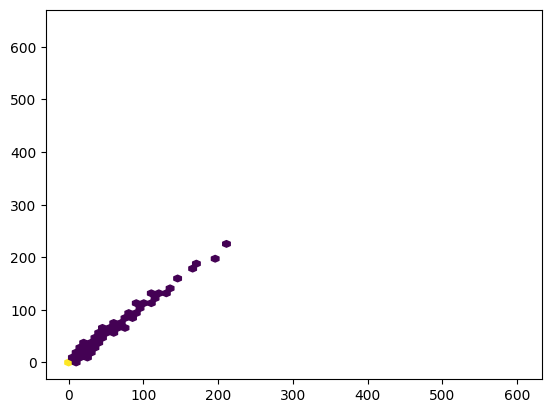

In [49]:
plt.hexbin(gdf["Area_PW"], gdf["area_km2_gswl"], gridsize=60, mincnt=2)

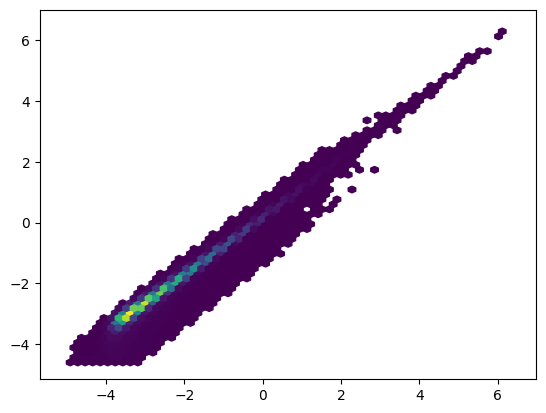

In [ ]:
plt.hexbin(np.log(gdf["Area_PW"]), np.log(gdf["area_km2_gswl"]), gridsize=60, mincnt=2)

/var/folders/rv/sn0kln2103b9fs4xl56n3w7w0000gn/T/ipykernel_53151/2838955106.py:2: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


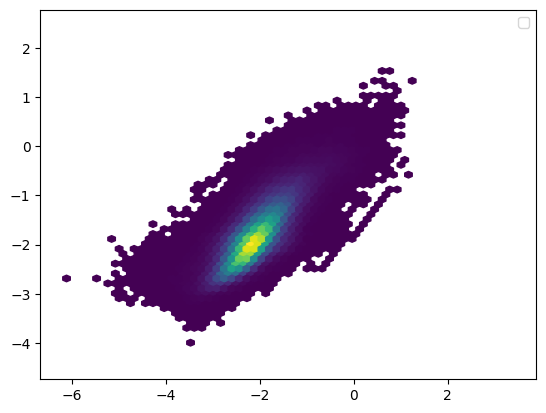

In [ ]:
plt.hexbin(np.log(gdf["dyn_ratio"]), np.log(gdf["dyn_ratio_gswl"]), gridsize=60, mincnt=2)
plt.legend()

/var/folders/rv/sn0kln2103b9fs4xl56n3w7w0000gn/T/ipykernel_53151/105499435.py:2: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


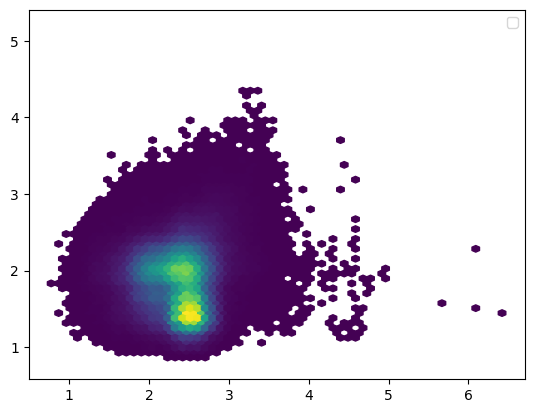

In [38]:
plt.hexbin(np.log(gdf["Dmax_use_m"]), np.log(gdf["Zmax_gswl"]), gridsize=60, mincnt=2)
plt.legend()

# Plots

## First, start with only vars available for small lakes, I.E from GGSWL

In [7]:
gdf.LEV_p2.describe()

count    220316.000000
mean          4.238970
std          79.704769
min           0.000000
25%           0.000000
50%           0.000000
75%           1.241037
max       25610.360393
Name: LEV_p2, dtype: float64

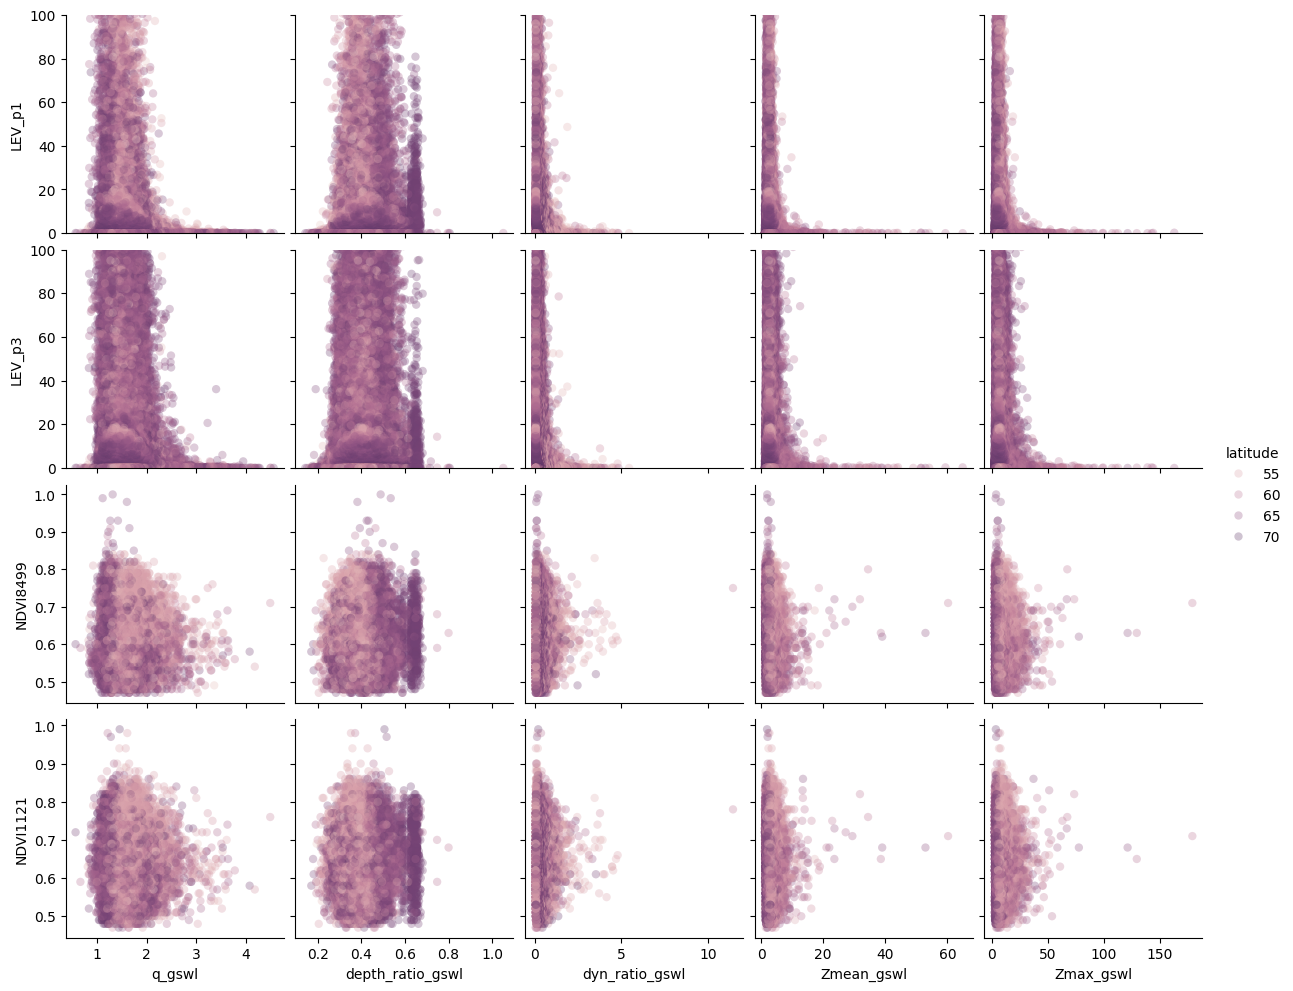

In [14]:
g = sns.pairplot(
    gdf,
    x_vars=["q_gswl", "depth_ratio_gswl", "dyn_ratio_gswl", "Zmean_gswl", "Zmax_gswl"],
    y_vars=["LEV_p1", "LEV_p3", "NDVI8499", "NDVI1121"],
    plot_kws={"alpha": 0.3, "edgecolor": "none"},
    hue="latitude",
)
[g.axes[i, 0].set_ylim([0, 100]) for i in [0, 1]]  # rm outliers
plt.savefig(os.path.join(plot_dir, "pairplot_hypsog_liu.png"), dpi=300)

In [8]:
# clip LEV_p1, LEV_p2, LEV_p3 to [0, 100]
# more not needed thanks to code that computes extents below
cols = ["LEV_p1", "LEV_p2", "LEV_p3"]
gdf[cols] = gdf[cols].clip(0, 100)

In [9]:
# rm outliers for plotting ease
for col in ["LEV_p13ain", "LEV_p13rin"]:
    low, high = gdf[col].quantile([0.02, 0.98])
    gdf.loc[(gdf[col] < low) | (gdf[col] > high), col] = np.nan

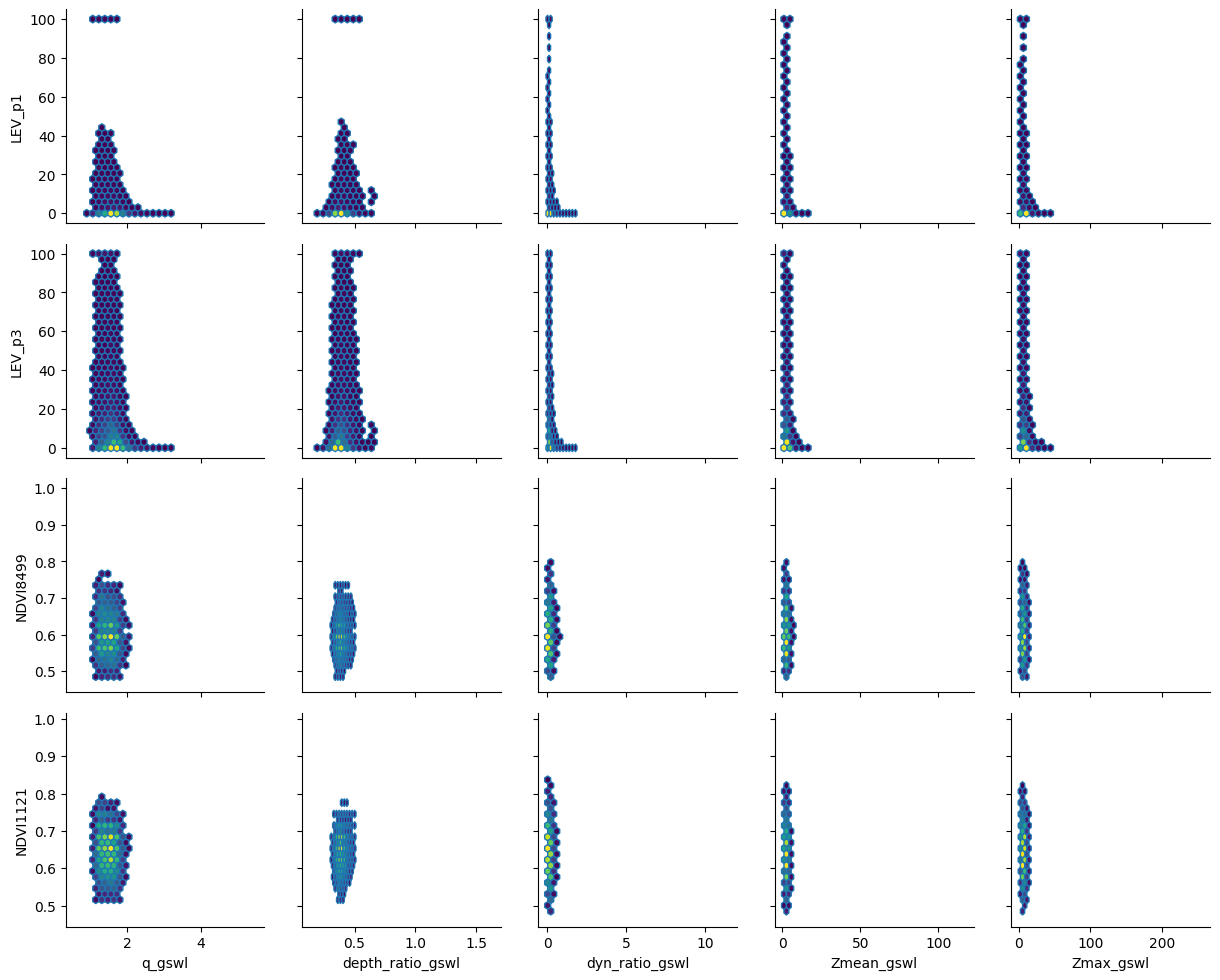

In [27]:
g = sns.PairGrid(
    gdf,
    x_vars=["q_gswl", "depth_ratio_gswl", "dyn_ratio_gswl", "Zmean_gswl", "Zmax_gswl"],
    y_vars=["LEV_p1", "LEV_p3", "NDVI8499", "NDVI1121"],
    # extent=...
    # hue="latitude",
)
g.map(lambda x, y, **kws: plt.hexbin(x, y, gridsize=30, mincnt=100, cmap="viridis", **kws))
# g.add_legend()

plt.savefig(os.path.join(plot_dir, "pairplot_hypsog_liu_hex.png"), dpi=300)

Custom code to use specific extents for the hexbin plot

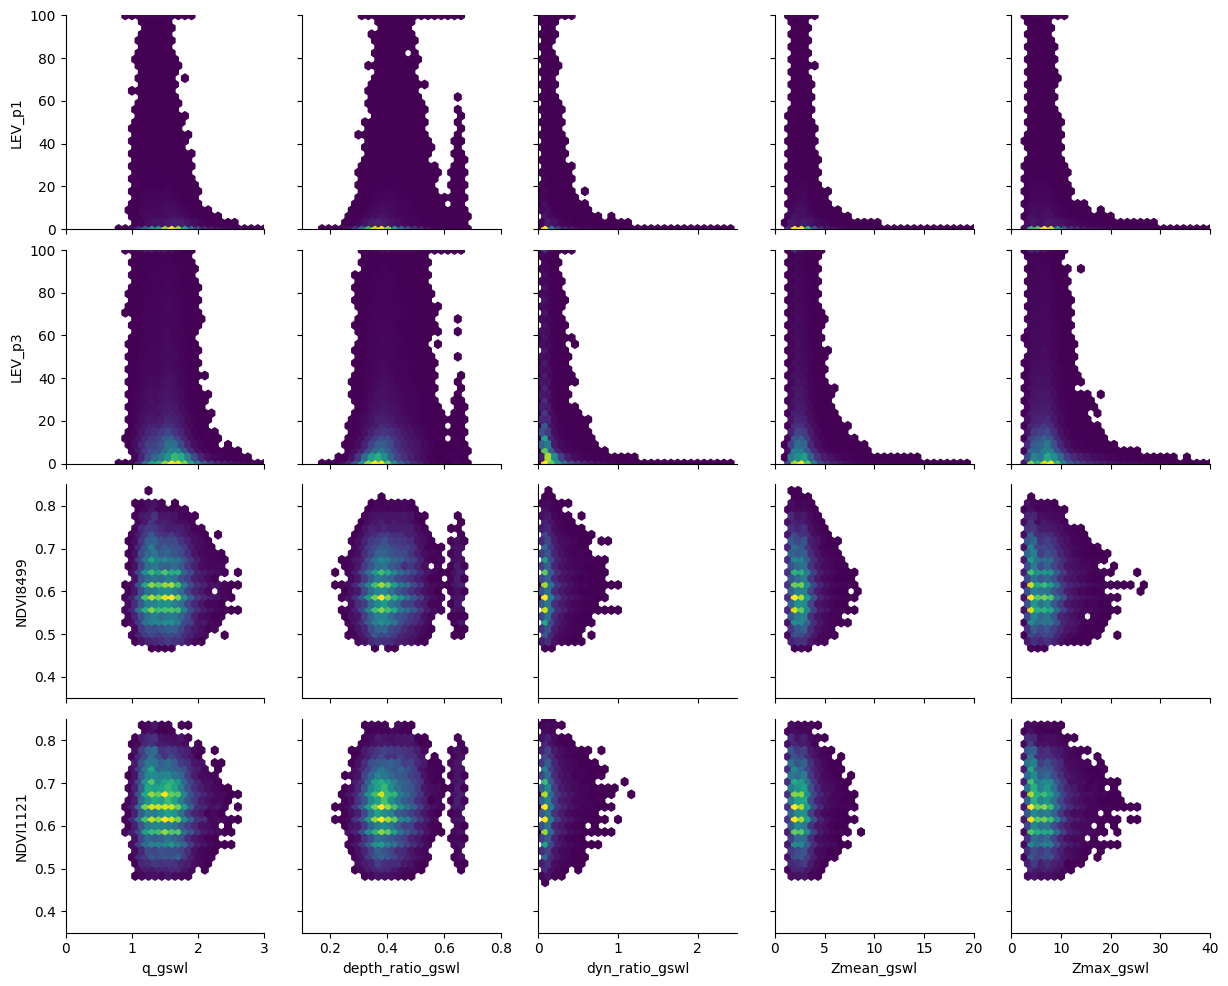

In [44]:
x_extents = [(0, 3), (0.1, 0.8), (0, 2.5), (0, 20), (0, 40)]
y_extents = [(0, 100), (0, 100), (0.35, 0.85), (0.35, 0.85)]

g = sns.PairGrid(
    gdf,
    x_vars=["q_gswl", "depth_ratio_gswl", "dyn_ratio_gswl", "Zmean_gswl", "Zmax_gswl"],
    y_vars=["LEV_p1", "LEV_p3", "NDVI8499", "NDVI1121"],
)

for i, (xlim, axcol) in enumerate(zip(x_extents, g.axes.T)):
    for j, (ylim, ax) in enumerate(zip(y_extents, axcol)):
        extent = (*xlim, *ylim)
        x = g.x_vars[i]
        y = g.y_vars[j]
        plt.sca(ax)
        plt.hexbin(gdf[x], gdf[y], gridsize=30, mincnt=10, cmap="viridis", extent=extent)
        plt.xlim(extent[:2])
        plt.ylim(extent[2:])

plt.savefig(os.path.join(plot_dir, "pairplot_hypsog_liu_hex_windowed.png"), dpi=300)

## further transformations

In [10]:
# create log-transformed versions of the x variables used above
x_vars = [
    "q_gswl",
    "depth_ratio_gswl",
    "dyn_ratio_gswl",
    "Zmean_gswl",
    "Zmax_gswl",
    "mean_bound_dist",
]
log_cols = [f"log_{v}" for v in x_vars]

for v, lc in zip(x_vars, log_cols):
    # set to NaN where values are non-positive to avoid -inf
    gdf[lc] = np.where(gdf[v] > 0, np.log(gdf[v]), np.nan)

# quick sanity check
gdf[log_cols].head()

,log_q_gswl,log_depth_ratio_gswl,log_dyn_ratio_gswl,log_Zmean_gswl,log_Zmax_gswl,log_mean_bound_dist
0,0.937426,-1.267904,0.868982,2.332144,3.600048,6.952652
1,0.437622,-0.935709,1.563214,1.629241,2.564949,6.424087
2,0.899844,-1.562648,0.717414,2.385081,3.947729,5.697443
3,1.063569,-1.583287,0.820442,2.270886,3.854173,6.783778
4,0.818057,-0.988312,1.546848,1.500753,2.489065,7.394822


In [11]:
# Add LZ area est from Casas-Ruiz paper (3m cutoff)
z_c = 3 # compensation depth, 1% of light
gdf["lz_frac"] = 1 - (1 - z_c / gdf.Zmax_gswl) ** (gdf.Zmax_gswl / gdf.Zmean_gswl - 1)

In [12]:
# delta NDVI
gdf["NDVI_p13ain"] = gdf.NDVI1121 - gdf.NDVI8499
gdf["NDVI_p23ain"] = gdf.NDVI1121 - gdf.NDVI0010

Plot with log x

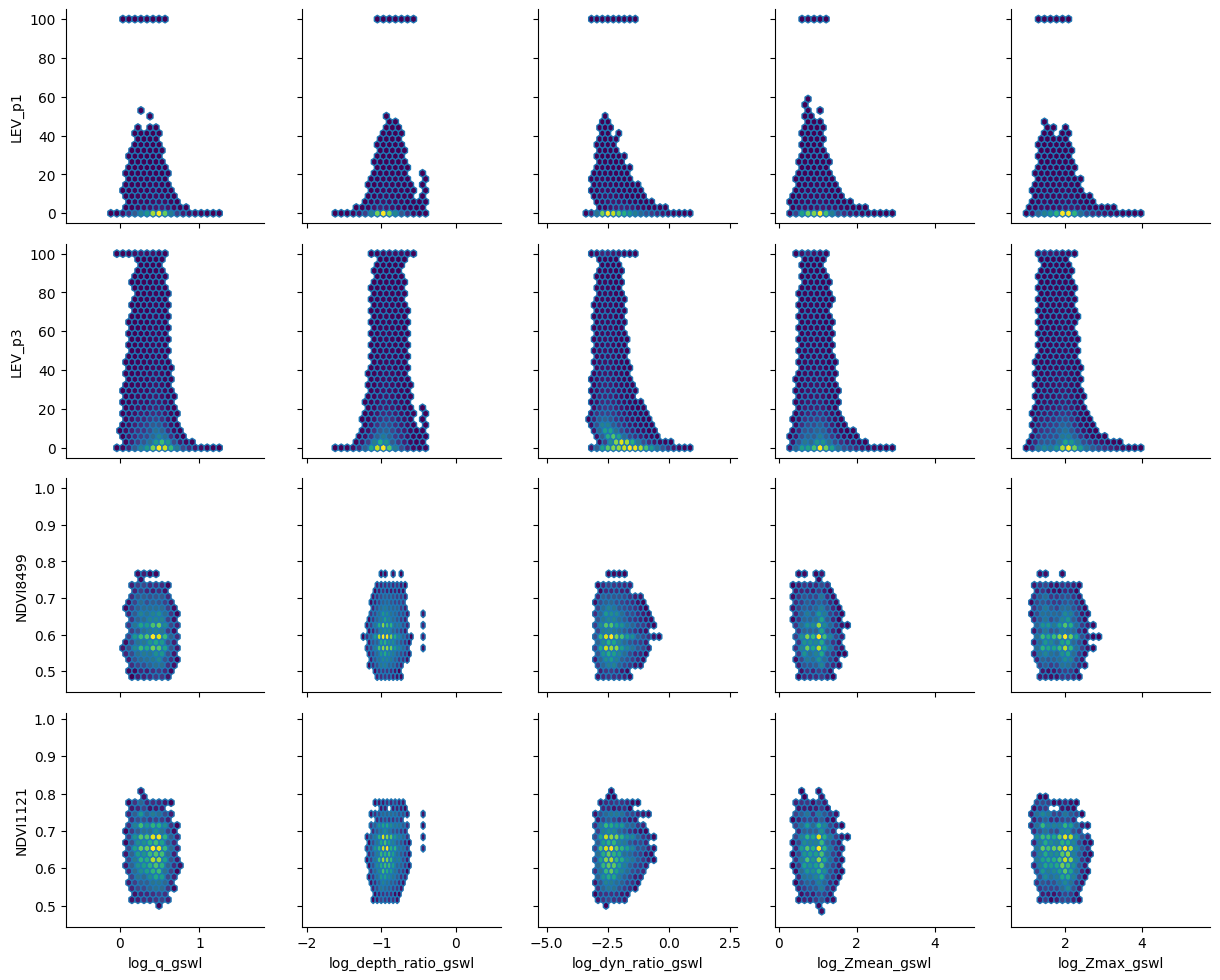

In [46]:
g = sns.PairGrid(
    gdf,
    x_vars=log_cols,
    y_vars=["LEV_p1", "LEV_p3", "NDVI8499", "NDVI1121"],
)
g.map(lambda x, y, **kws: plt.hexbin(x, y, gridsize=30, mincnt=60, cmap="viridis", **kws))
plt.savefig(os.path.join(plot_dir, "pairplot_hypsog_liu_hex_log.png"), dpi=300)

Plot with lit zone and Kuhn greenness

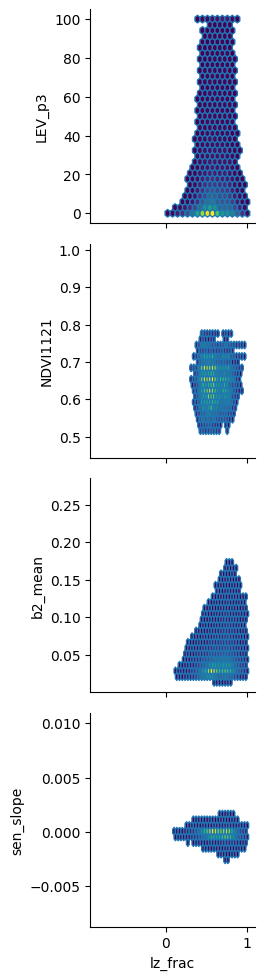

In [53]:
g = sns.PairGrid(
    gdf,
    x_vars=["lz_frac"],
    y_vars=["LEV_p3", "NDVI1121", "b2_mean", "sen_slope"],

)
g.map(lambda x, y, **kws: plt.hexbin(x, y, gridsize=30, mincnt=40, cmap="viridis", **kws))
# g.add_legend()

plt.savefig(os.path.join(plot_dir, "pairplot_hypsog_liu_kuhn_hex.png"), dpi=300)

Same, but indiv plot control

Findings:
* Only noticeable trend at the individual lake level is with LEVP3 (and to much lesser extent P1 and P2, probably due to lower sensor SNR)
* Varies with dyn ratio and mean bound dist, but not 3m zone percentage.


In [15]:
y_vars = [
    "LEV_p1",
    "LEV_p2",
    "LEV_p3",
    "NDVI1121",
    "b2_mean",
    "sen_slope",
    "LEV_p13ain",
    "LEV_p13rin",
    "NDVI_p13ain",
    "NDVI_p23ain",
]

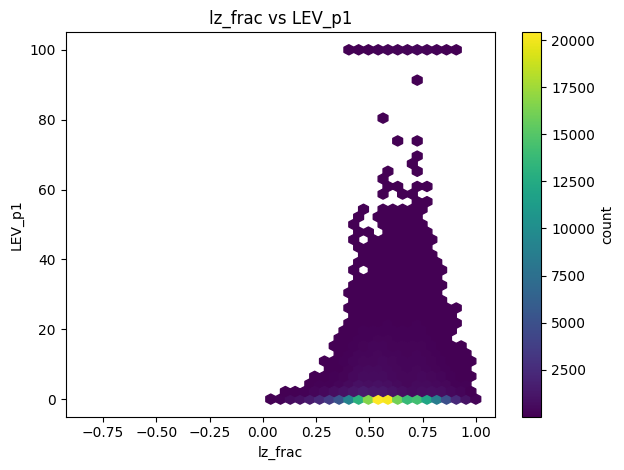

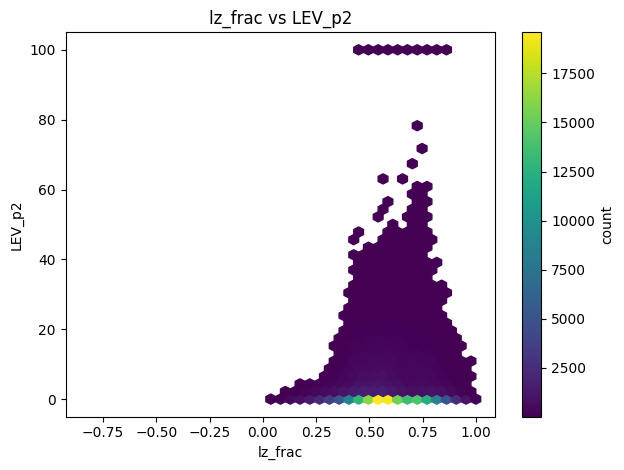

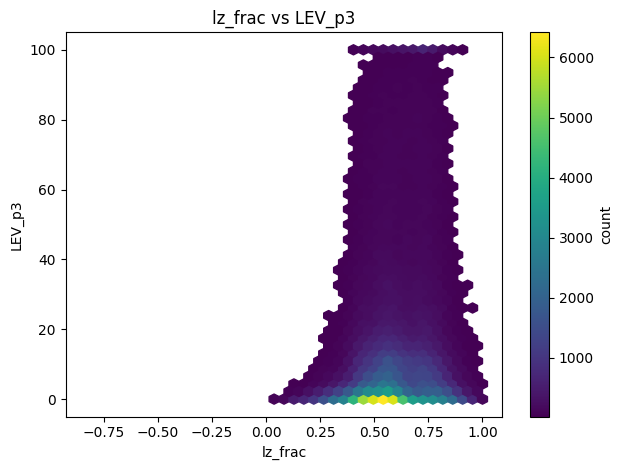

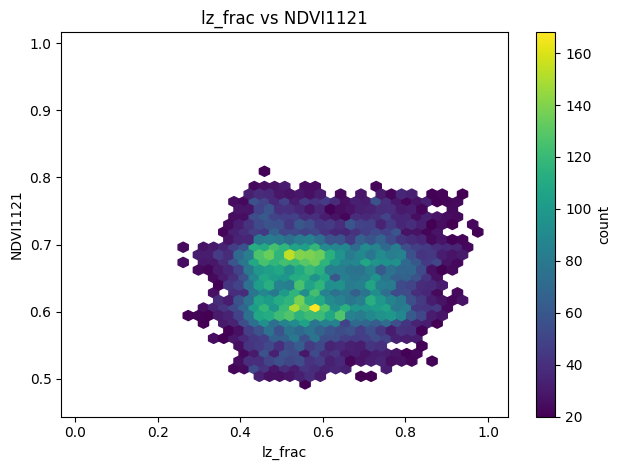

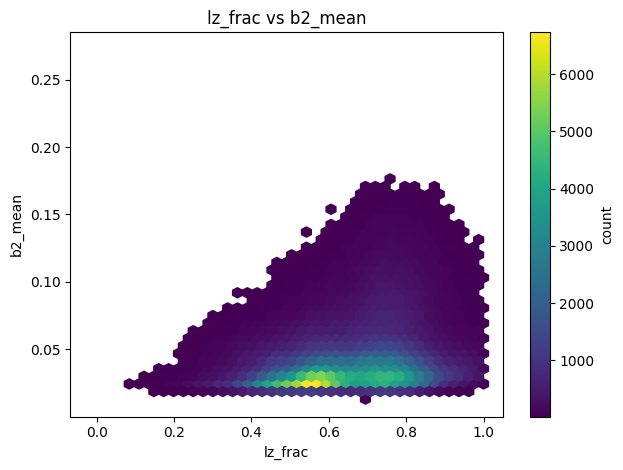

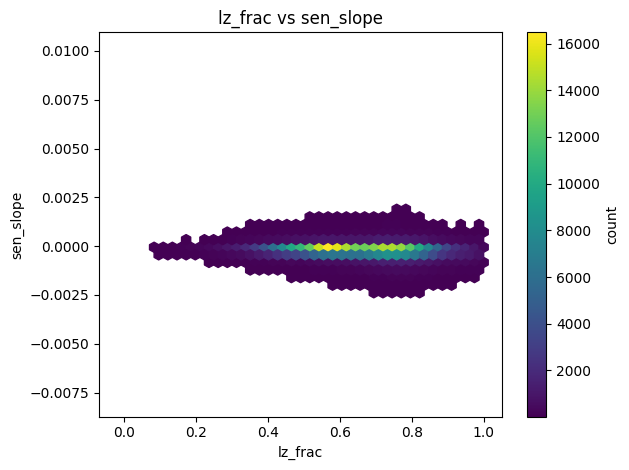

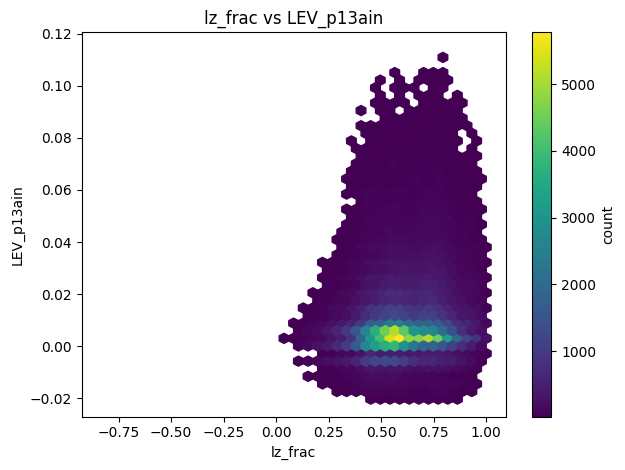

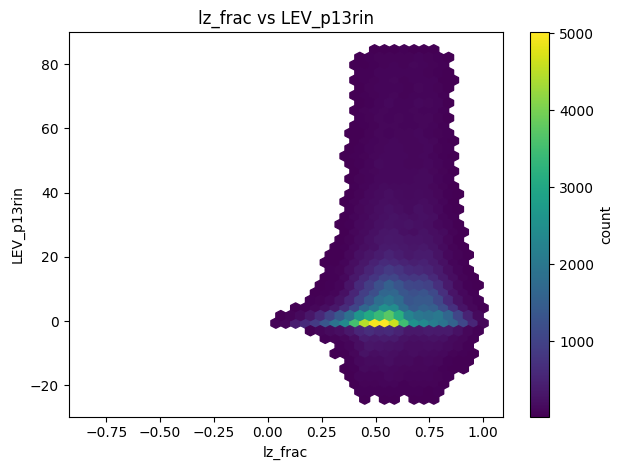

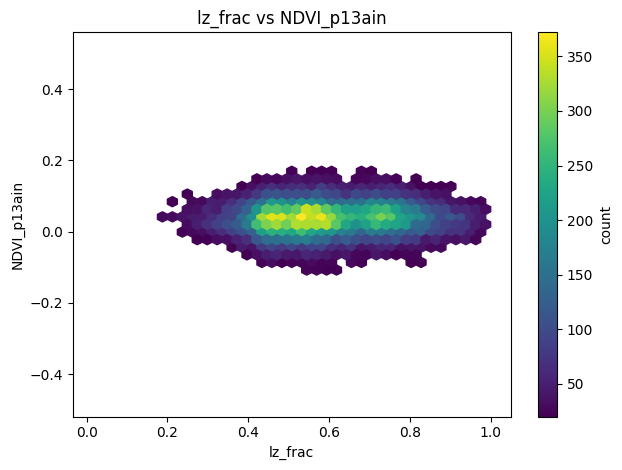

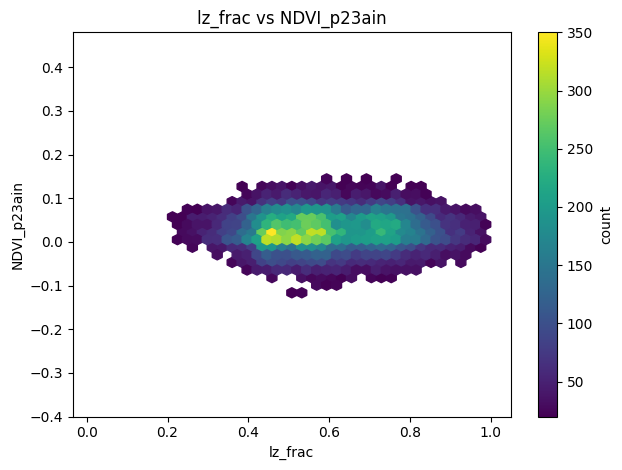

In [ ]:
x = "lz_frac"

for y in y_vars:
    plt.figure()
    plt.hexbin(gdf[x], gdf[y], gridsize=40, mincnt=20, cmap="viridis")
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(f"{x} vs {y}")
    plt.colorbar(label="count")
    plt.tight_layout()

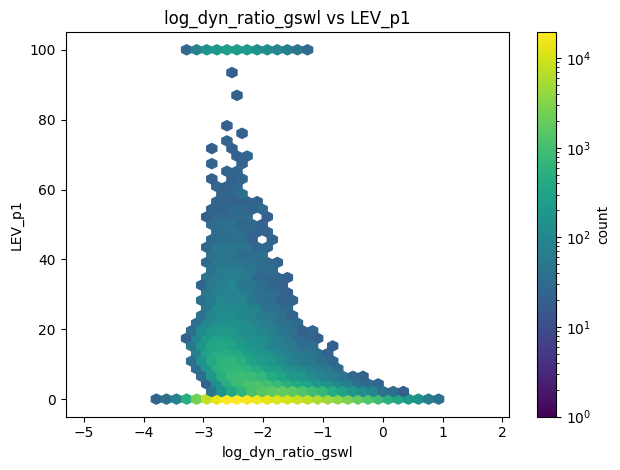

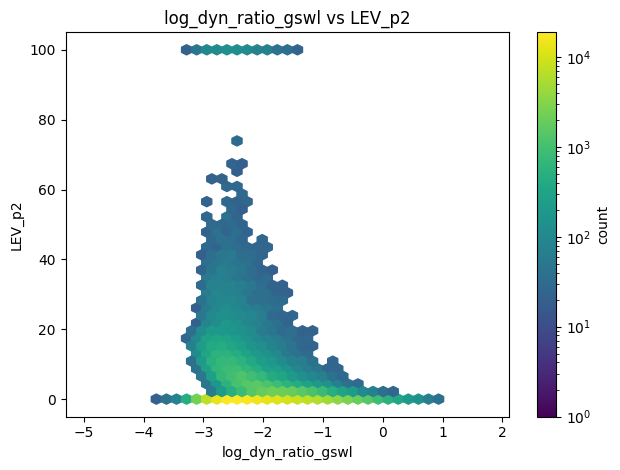

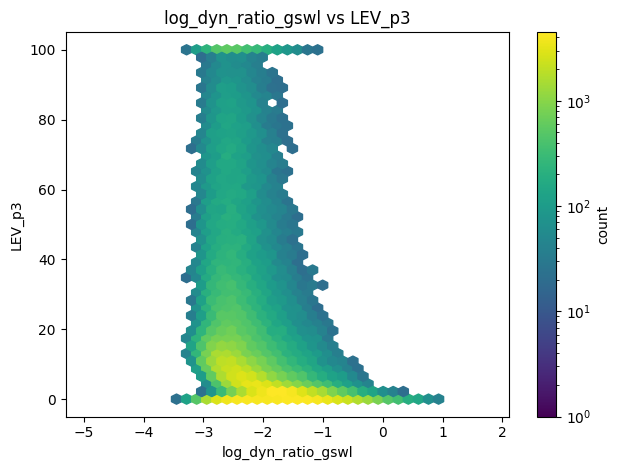

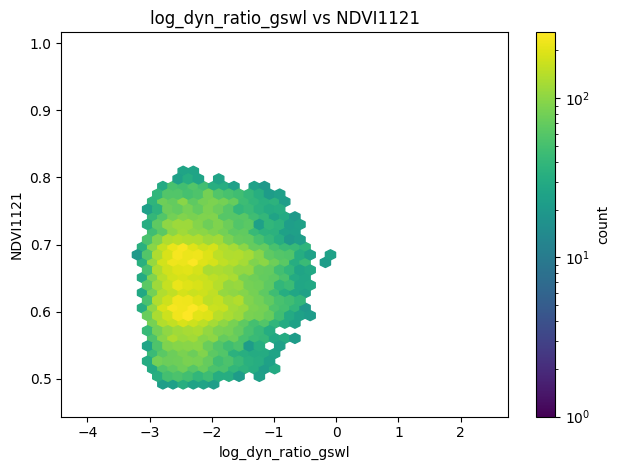

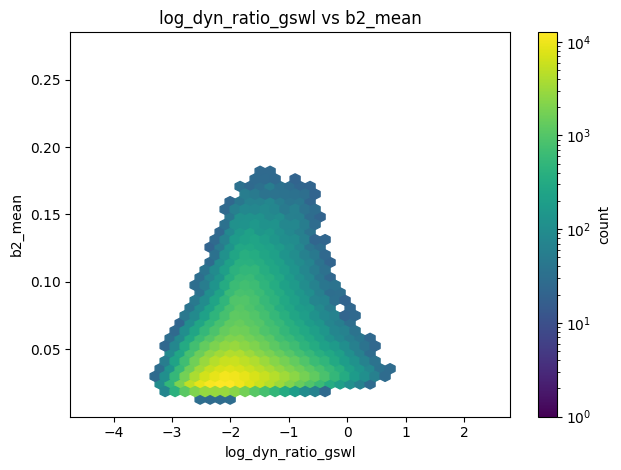

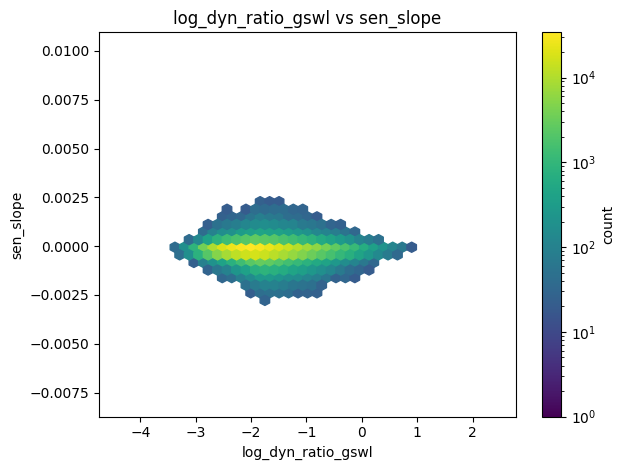

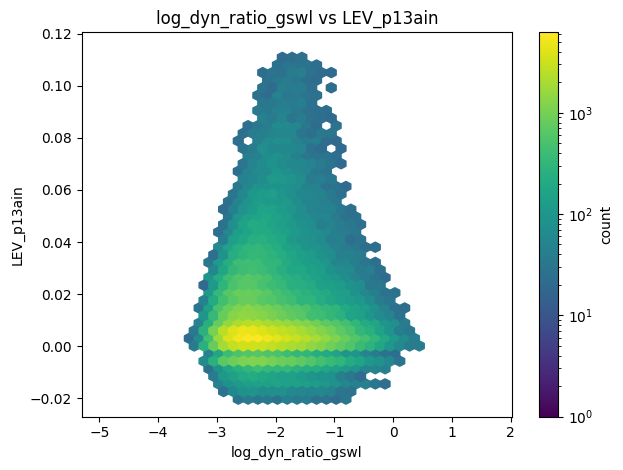

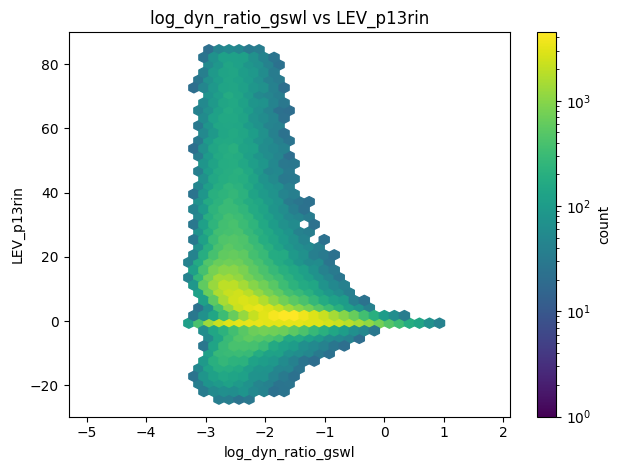

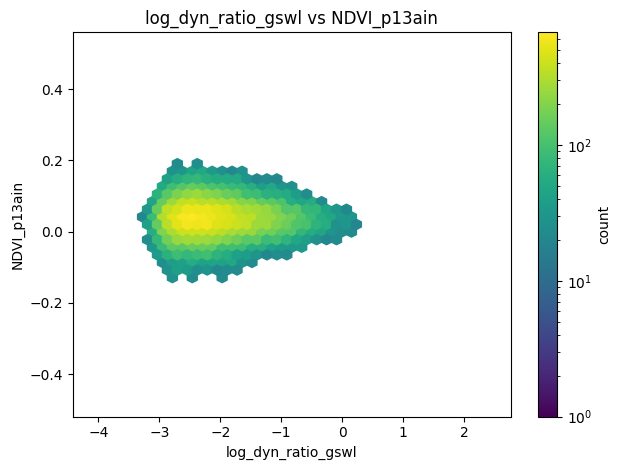

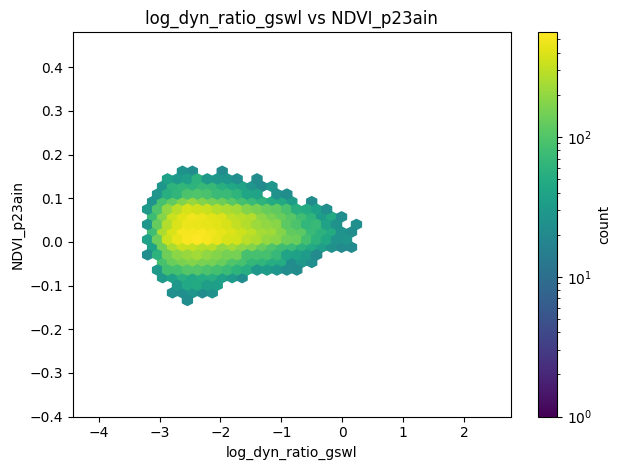

In [ ]:
x = "log_dyn_ratio_gswl"
for y in y_vars:
    plt.figure()
    plt.hexbin(
        gdf[x], gdf[y], gridsize=40, mincnt=20, cmap="viridis", norm=LogNorm(vmin=1)
    )  # , vmax=2500)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(f"{x} vs {y}")
    plt.colorbar(label="count")
    plt.tight_layout()

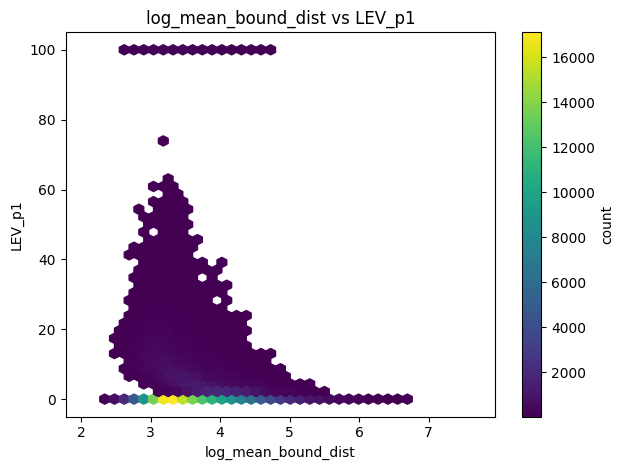

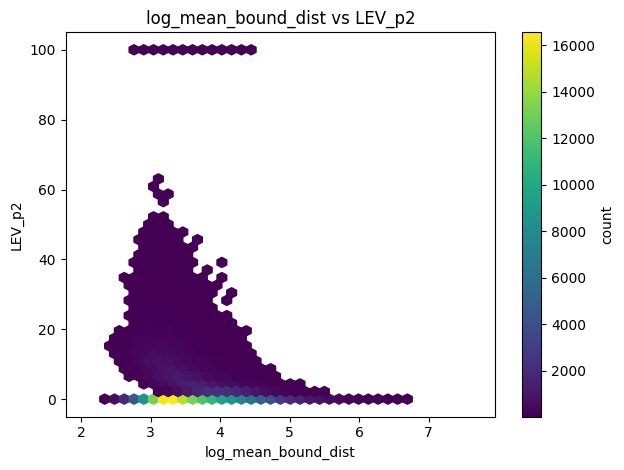

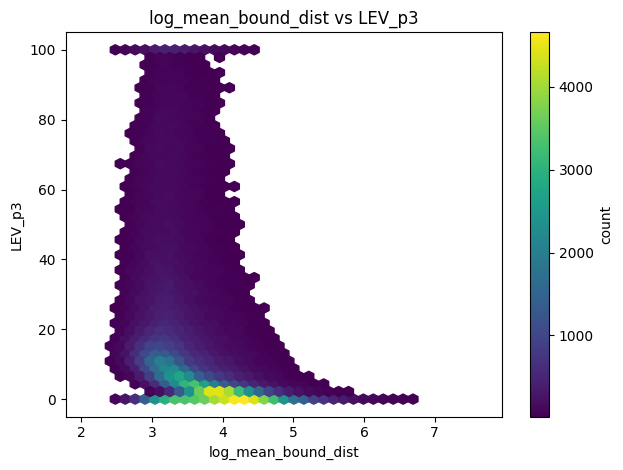

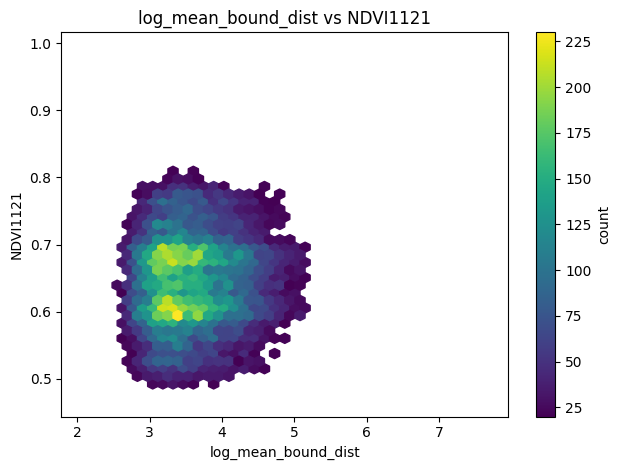

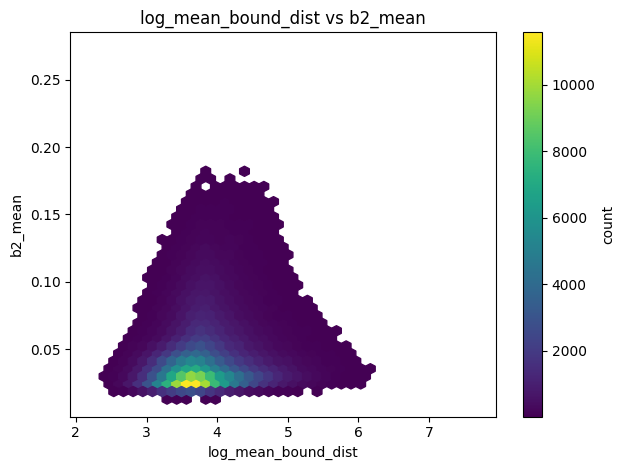

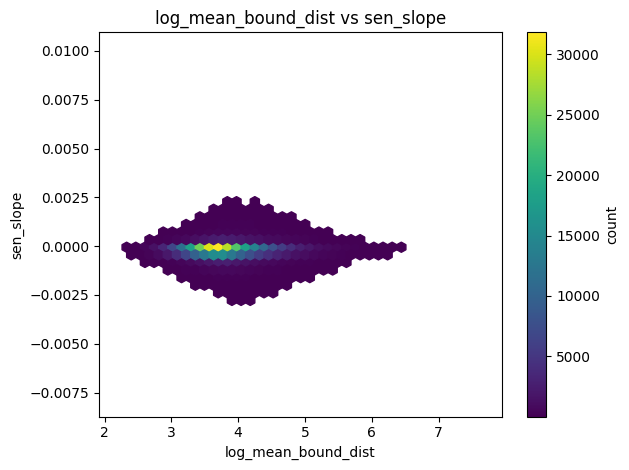

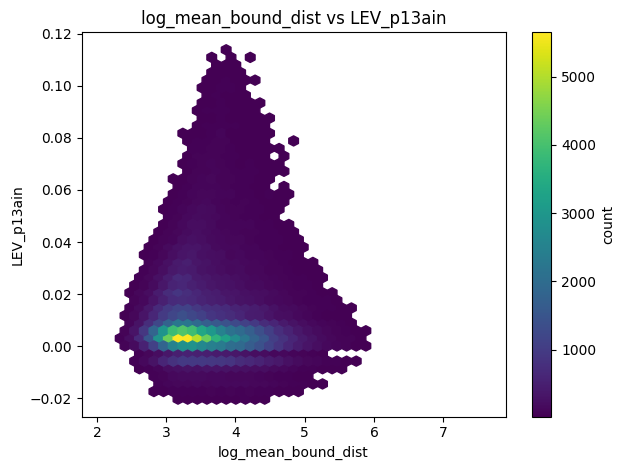

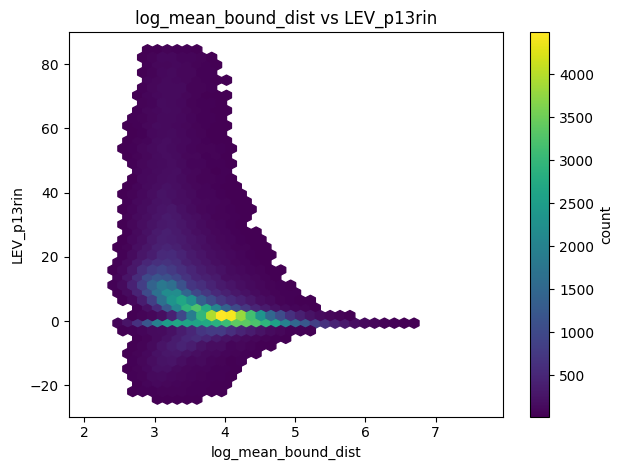

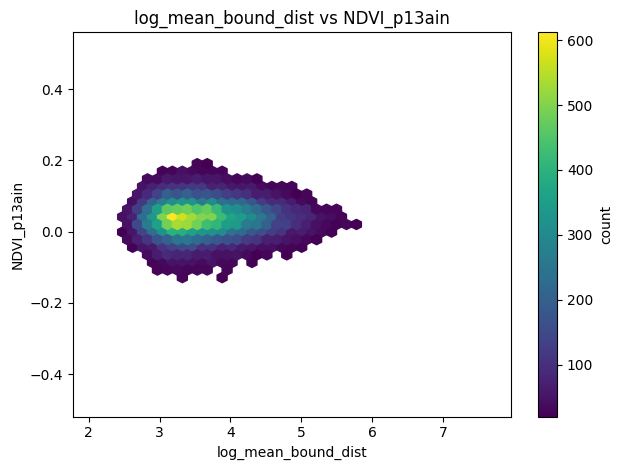

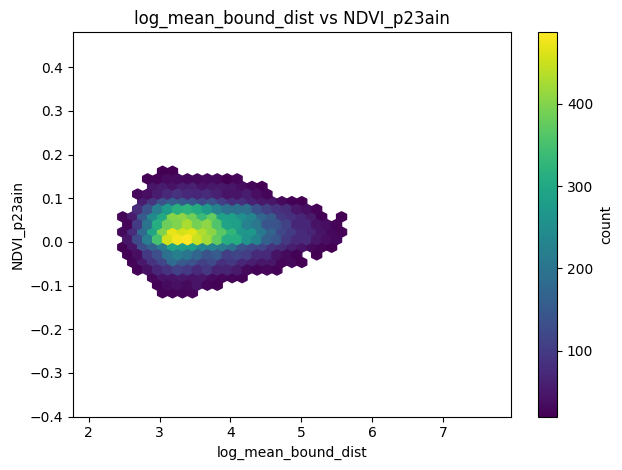

In [17]:
x = "log_mean_bound_dist"
for y in y_vars:
    plt.figure()
    plt.hexbin(gdf[x], gdf[y], gridsize=40, mincnt=20, cmap="viridis")
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(f"{x} vs {y}")
    plt.colorbar(label="count")
    plt.tight_layout()

# View plots in folder

In [ ]:
plot_dir

'/Volumes/metis/ABOVE3/fig'

In [ ]:
# %%bash
!ls {plot_dir}

bound_green_hex_2.png
bound_lev_hex_2.png
bound_lev_kde_2.png
bound_ndvi_hex_2.png
green_lev_hexbin_2.png
green_lev_kde.png
green_lev_kde_2.png
green_lev_trend.png
green_lev_trend_2.png
green_lev_trend_hexbin_2.png
pairplot_aleb_pco2_green.png
pairplot_aleb_pco2_green_kde.png
pairplot_aleb_pco2_morph.png
pairplot_greenness_icrms.png
pairplot_greenness_opt.png
pairplot_hypsog_liu.png
pairplot_hypsog_liu_hex.png
pairplot_hypsog_liu_hex_log.png
pairplot_hypsog_liu_hex_windowed.png
pairplot_hypsog_liu_hex_windowed_log.png
pairplot_icrms_morph.png
pairplot_kurek_cherrypick_v1.png
pairplot_kurek_cherrypick_v2.png
pairplot_opt_morph.png
qgis figs alias
ternary_aleb.png
ternary_kurek_region.png


In [32]:
plot_dir

'/Volumes/metis/ABOVE3/fig'

In [36]:
# %%bash
!ls {plot_dir}

bound_green_hex_2.png
bound_lev_hex_2.png
bound_lev_kde_2.png
bound_ndvi_hex_2.png
green_lev_hexbin_2.png
green_lev_kde.png
green_lev_kde_2.png
green_lev_trend.png
green_lev_trend_2.png
green_lev_trend_hexbin_2.png
pairplot_aleb_pco2_green.png
pairplot_aleb_pco2_green_kde.png
pairplot_aleb_pco2_morph.png
pairplot_greenness_icrms.png
pairplot_greenness_opt.png
pairplot_hypsog_liu.png
pairplot_hypsog_liu_hex.png
pairplot_hypsog_liu_hex_log.png
pairplot_hypsog_liu_hex_windowed.png
pairplot_hypsog_liu_hex_windowed_log.png
pairplot_icrms_morph.png
pairplot_kurek_cherrypick_v1.png
pairplot_kurek_cherrypick_v2.png
pairplot_opt_morph.png
qgis figs alias
ternary_aleb.png
ternary_kurek_region.png


# Plot the region with the trend

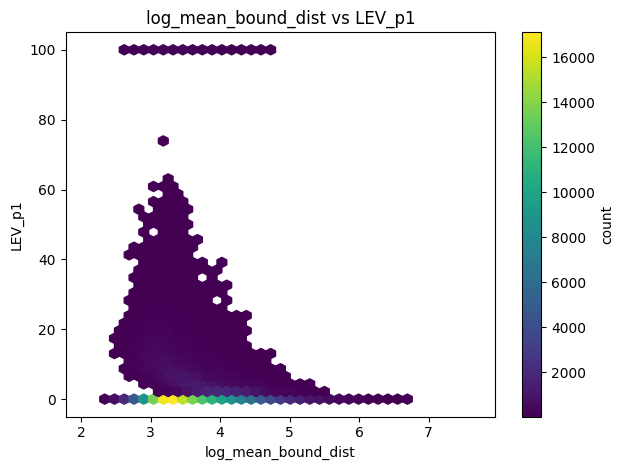

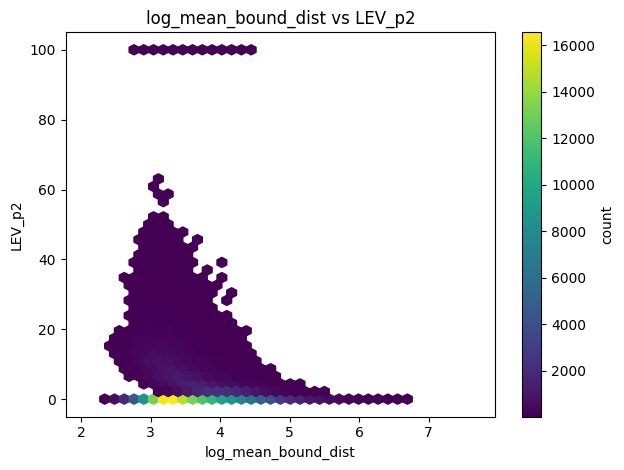

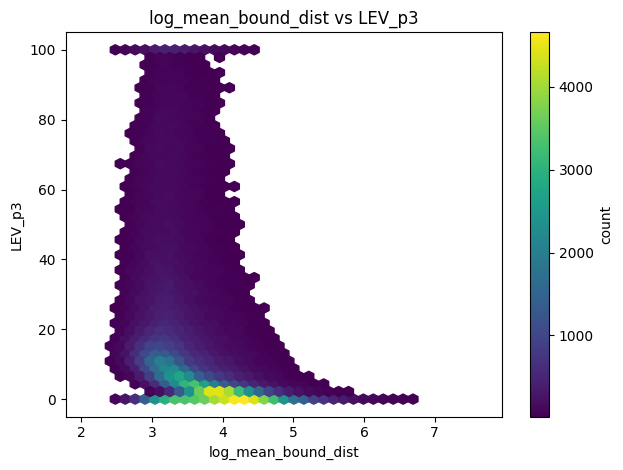

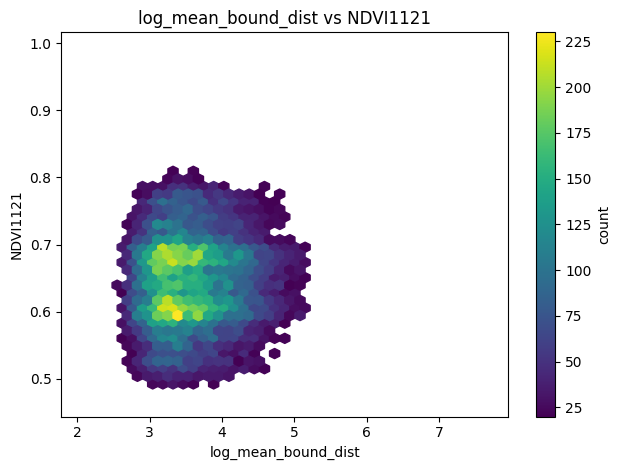

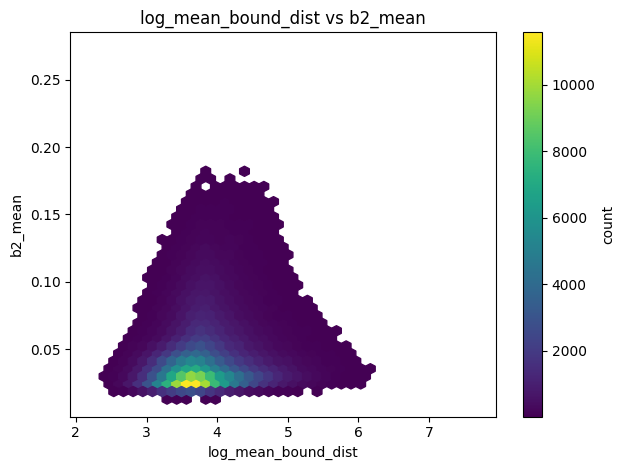

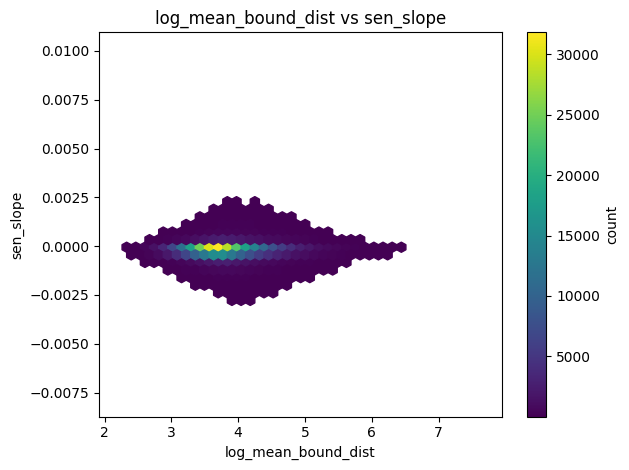

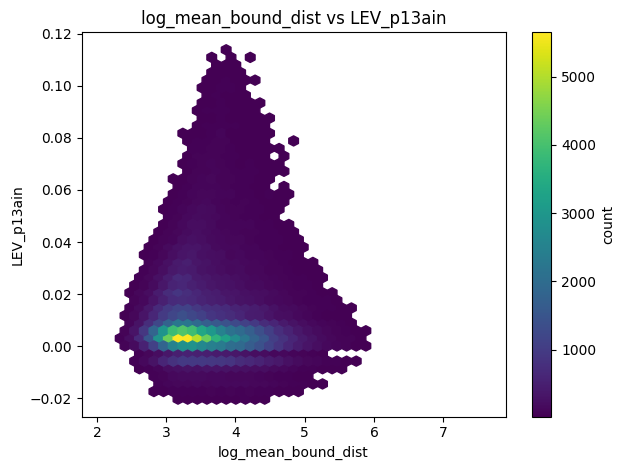

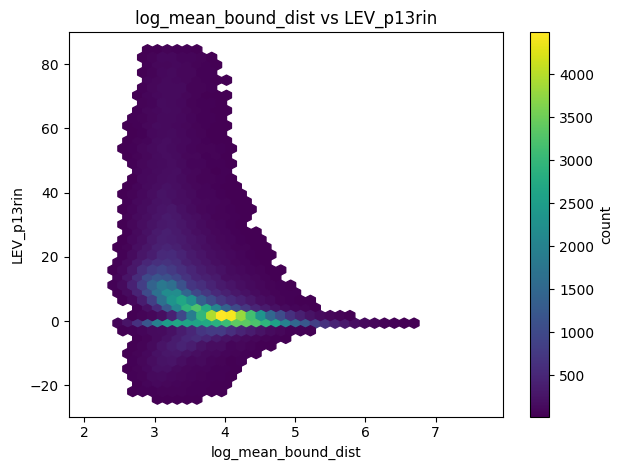

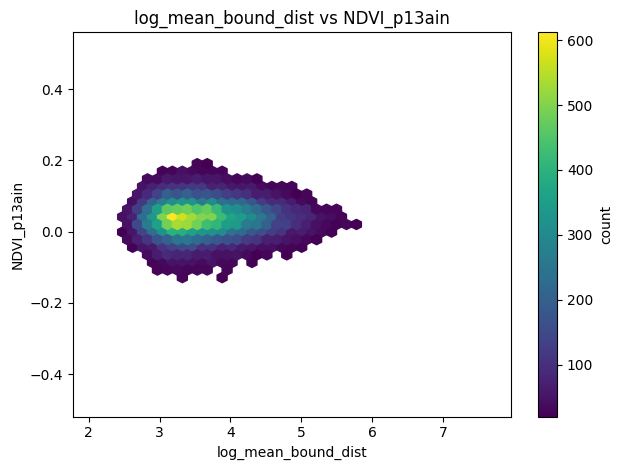

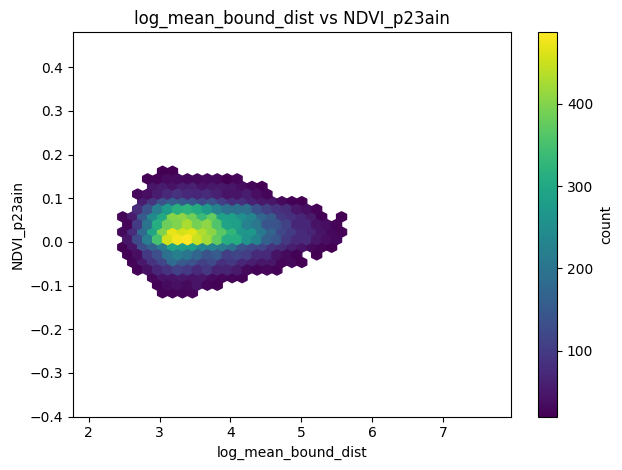

In [ ]:
x = "mean_bound_dist"
y = "LEVp3"
plt.figure()
plt.hexbin(gdf[x], gdf[y], gridsize=40, mincnt=20, cmap="viridis")
plt.xlabel(x)
plt.ylabel(y)
plt.title(f"{x} vs {y}")
plt.colorbar(label="count")
plt.tight_layout()